### Petrea Norgren, Siri Strøm


# 🌳 Decision Tree & Random Forest

To be sent razan.mhanna@inria.fr before 28 March 2025.

Decision Trees are an important type of algorithm for predictive modeling machine learning.

The classical decision tree algorithms have been around for decades and modern variations like random forest are among the most powerful techniques available.

Classification and Regression Trees or `CART` for short is a term introduced by `Leo Breiman` to refer to Decision Tree algorithms that can be used for classification or regression predictive modeling problems.

Classically, this algorithm is referred to as “`decision trees`”, but on some platforms like R they are referred to by the more modern term CART.

The `CART` algorithm provides a foundation for important algorithms like `bagged decision trees`, `random forest` and `boosted decision trees`.

### CART Model Representation
The representation for the CART model is a binary tree.

This is your binary tree from algorithms and data structures, nothing too fancy. Each root node represents a single input variable (x) and a split point on that variable (assuming the variable is numeric).

The leaf nodes of the tree contain an output variable (y) which is used to make a prediction.

Given a new input, the tree is traversed by evaluating the specific input started at the root node of the tree.

#### Some **advantages** of decision trees are:
* Simple to understand and to interpret. Trees can be visualised.
* Requires little data preparation.
* Able to handle both numerical and categorical data.
* Possible to validate a model using statistical tests.
* Performs well even if its assumptions are somewhat violated by the true model from which the data were generated.

#### The **disadvantages** of decision trees include:
* Overfitting. Mechanisms such as pruning (not currently supported), setting the minimum number of samples required at a leaf node or setting the maximum depth of the tree are necessary to avoid this problem.
* Decision trees can be unstable. Mitigant: Use decision trees within an ensemble.
* Cannot guarantee to return the globally optimal decision tree. Mitigant: Training multiple trees in an ensemble learner
* Decision tree learners create biased trees if some classes dominate. Recommendation: Balance the dataset prior to fitting

# Random Forest
Random Forest is one of the most popular and most powerful machine learning algorithms. It is a type of ensemble machine learning algorithm called Bootstrap Aggregation or bagging.


## Load necessary libraries
You will start by importing the necessary libraries for this lab.

In [1]:
# Importing necessary tensorflow library and printing the TF version.
import tensorflow as tf

print("TensorFlow version: ",tf.version.VERSION)


TensorFlow version:  2.21.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Dataset description
Kyphosis is a spinal disorder in which an excessive outward curve of the spine results in an abnormal rounding of the upper back. The condition is sometimes known as "roundback" or—in the case of a severe curve—as "hunchback." Kyphosis can occur at any age, but is common during adolescence. There are many patients who get operated for kyphosis and even after the operation the disorder may be present.

So the problem at hand is to predict looking at the various factors of the patient whether the patient still has kyphosis disorder after the operation or not.

The dataset contains the following columns:


1.   Kyphosis: This column represents that the patient had kyphosis and had a corrected spinal surgery operation. So this column basically tells whether the kyphosis condition was present or absent after the operation
2. Age: Age of the patient in months (The dataset is a children dataset)
3. Number: Number of vertebrae involved in the operation
4. Start: Number of the first or topmost vertebrae that was operated

In [10]:
# Reading "kyphosis.csv" file using the read_csv() function included in the pandas library
df = pd.read_csv('Dataset_3.csv')
#Added to remove unnecessary column 
df.drop(columns='Unnamed: 0', inplace=True)

In [11]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


## Exploratory Data Analysis

**Lab Task #1:** Check a pairplot for this small dataset.

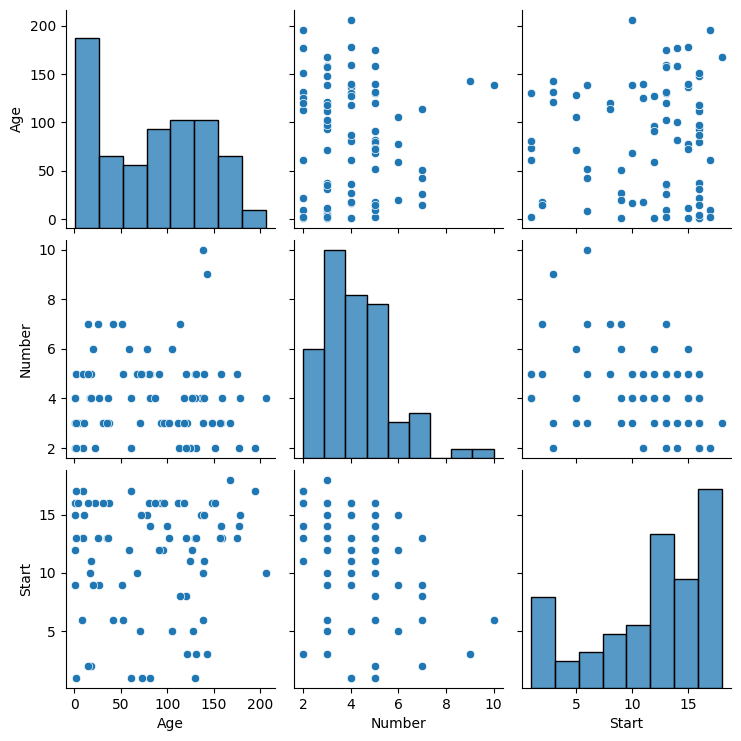

In [ ]:
# Use the pairplot() function to plot multiple pairwise bivariate distributions in a dataset
# EX 1

sns.pairplot(df)

## Train Test Split

Let's split up the data into a training set and a test set!

In [13]:
from sklearn.model_selection import train_test_split

In [23]:
# EX 2: Split the dataset into 70:30 train test split.
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Kyphosis'),df['Kyphosis'], test_size=0.3)
print('X_train shape: ', X_train.shape)
print('y_train shape: ', y_train.shape)
print('X_test shape: ', X_test.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (56, 3)
y_train shape:  (56,)
X_test shape:  (25, 3)
y_test shape:  (25,)


## Decision Trees

**EX 3:** Train a single decision tree.

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dtree = DecisionTreeClassifier()

In [26]:
# Train Decision Tree Classifer

dtree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction and Evaluation

**EX 4:** Evaluate your decision tree.

In [27]:
predictions = dtree.predict(X_test)

In [28]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
# build a text report showing the main classification metrics
#
cv = classification_report(y_test, predictions, output_dict=True)

print('Accuracy: ', cv['accuracy'])
print()



{'absent': {'precision': 0.9047619047619048,
  'recall': 0.8636363636363636,
  'f1-score': 0.8837209302325582,
  'support': 22.0},
 'present': {'precision': 0.25,
  'recall': 0.3333333333333333,
  'f1-score': 0.2857142857142857,
  'support': 3.0},
 'accuracy': 0.8,
 'macro avg': {'precision': 0.5773809523809523,
  'recall': 0.5984848484848485,
  'f1-score': 0.584717607973422,
  'support': 25.0},
 'weighted avg': {'precision': 0.8261904761904763,
  'recall': 0.8,
  'f1-score': 0.8119601328903654,
  'support': 25.0}}

In [36]:
# compute confusion matrix to evaluate the accuracy of a classification
#
confusion_matrix(y_test, predictions)


array([[19,  3],
       [ 2,  1]])

## Tree Visualization

Scikit learn actually has some built-in visualization capabilities for decision trees, you won't use this often and it requires you to install the pydot library, but here is an example of what it looks like and the code to execute this:

In [37]:
from io import StringIO  # Import StringIO from the io module
from sklearn.tree import export_graphviz
import pydot
from IPython.display import Image


In [38]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

features = list(df.columns[1:])
features

['Age', 'Number', 'Start']

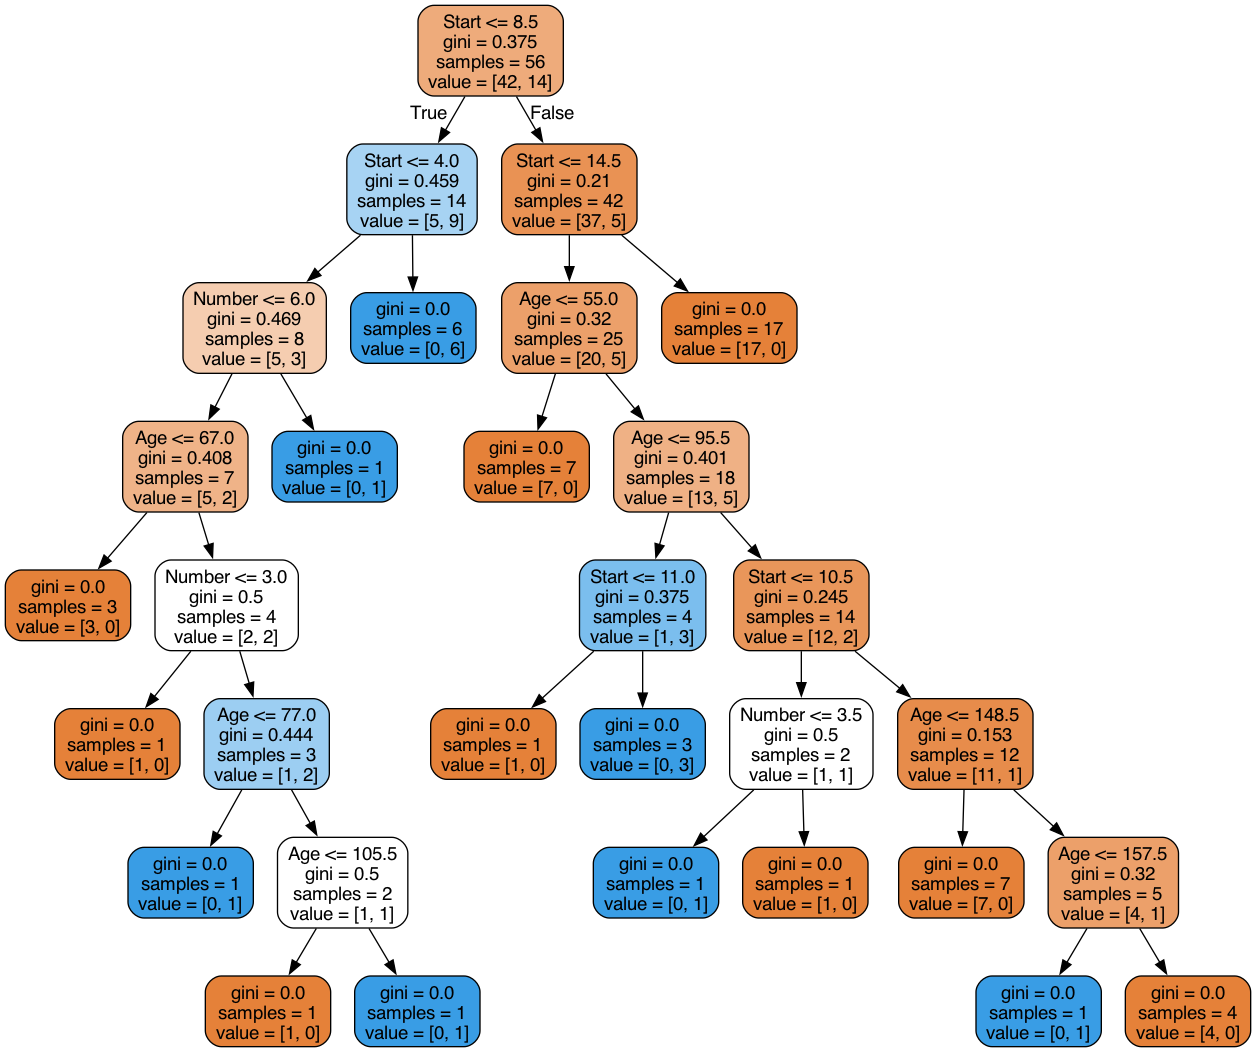

In [39]:
dot_data = StringIO()
export_graphviz(dtree, out_file=dot_data,feature_names=features,filled=True,rounded=True)

graph = pydot.graph_from_dot_data(dot_data.getvalue())
Image(graph[0].create_png())

**EX 5:** Interpret the figure, what does each leaf values mean? How the split is perfomed.


## Random Forests

**EX 6:** Compare the decision tree model to a random forest.

In [40]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rfc_pred = rfc.predict(X_test)

In [42]:
# compute confusion matrix to evaluate the accuracy
confusion_matrix(y_test, rfc_pred)

array([[21,  1],
       [ 2,  1]])

In [ ]:
# build a text report showing the main metrics

